# 3. Perturbation Prediction

Can a model predict transcriptome changes for a gene that was not knocked out in the
training data?

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from scipy import sparse
from scipy.stats import pearsonr, spearmanr, wilcoxon
import zipfile
import shap

from sklearn.model_selection import train_test_split, GroupKFold, cross_val_score
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve,
                             precision_recall_curve, accuracy_score, balanced_accuracy_score,
                             precision_score, recall_score, f1_score, classification_report)

import torch
import torch.nn as nn

import warnings
warnings.filterwarnings("ignore")

/home/benjamin/Code/miniconda3/envs/final_project/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Variable setup
DATA_DIR         = "./../data/frangieh"
REACTOME_GMT_ZIP = "./../data/ReactomePathways.gmt.zip"

CONDITION_COL = "perturbation_2"
PERT_COL      = "perturbation"
COCULTURE     = "Co-culture"
CONTROL_LABEL = "control"

N_PERTS        = 50
TEST_SIZE      = 0.2
N_TARGET_GENES = 2000
N_DE           = 100     # top |log2FC| genes counted as differentially expressed (for ROC/PR)
DE_THRESHOLD   = 1.0     # |log2FC| >= 1 (2-fold) = differentially expressed (for accuracy/precision/recall/f1)
SEED           = 0

I decided to try and train the model on all three conditions and not just co-culture.

In [3]:
# Load data
adata = sc.read_h5ad(f"{DATA_DIR}/rna_qc_normalized.h5ad")
print("RNA data:", adata)

protein_adata = sc.read_h5ad(f"{DATA_DIR}/protein.h5ad")
print("Protein data:", protein_adata)

# Match cells between RNA and protein
common_cells = adata.obs_names.intersection(protein_adata.obs_names)
adata = adata[common_cells].copy()
protein_adata = protein_adata[common_cells].copy()
print(f"Matched cells between RNA and protein: {len(common_cells)}")

# Normalize protein (arcsinh transformation for CITE-seq)
protein_X_raw = protein_adata.X.copy()
protein_X_raw = protein_X_raw.toarray() if sparse.issparse(protein_X_raw) else np.asarray(protein_X_raw)
protein_X_normalized = np.arcsinh(protein_X_raw / 5)
protein_adata.X = protein_X_normalized

RNA data: AnnData object with n_obs × n_vars = 218331 × 23712
    obs: 'library_preparation_protocol', 'perturbation_2', 'MOI', 'sgRNA', 'UMI_count', 'guide_id', 'perturbation', 'tissue_type', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'perturbation_type_2', 'nperts', 'ngenes', 'ncounts', 'percent_mito', 'percent_ribo', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
    var: 'ensembl_id', 'ncounts', 'ncells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hv

Get an overview of the class distributions.

In [4]:
obs = adata.obs
print(f"cells: {adata.n_obs:,}   genes: {adata.n_vars:,}")

print("\ncells per condition:")
print(obs[CONDITION_COL].value_counts())

print("\ncontrol cells per condition:")
print(obs.loc[obs[PERT_COL] == CONTROL_LABEL, CONDITION_COL].value_counts())

cells: 218,331   genes: 23,712

cells per condition:
perturbation_2
IFNγ          87590
Co-culture    73114
Control       57627
Name: count, dtype: int64

control cells per condition:
perturbation_2
IFNγ          23910
Co-culture    18334
Control       15361
Name: count, dtype: int64


I decided to use pseudobulk for training the models, as I will have to predict the log2FC anyway. Taking pseudobulk will save me a lot of compute and even if I train on count matrices I will have to average in the end anyways.

In [5]:
# Pseudobulk log2FC (per condition and perturbation)
counts = adata.layers["counts"]
counts = counts.tocsr() if sparse.issparse(counts) else np.asarray(counts)
perts_all = adata.obs[PERT_COL].astype(str).values
cond_all  = adata.obs[CONDITION_COL].astype(str).values
genes     = adata.var_names
CONDITIONS = sorted(pd.unique(cond_all))
print(f"conditions: {CONDITIONS}")

def pseudobulk_cpm(mask):
    total = np.asarray(counts[mask].sum(axis=0)).ravel()   # summed counts per gene
    return total / total.sum() * 1e6                       # CPM

rows, rows_protein = {}, {}
n_drop = 0
for c in CONDITIONS:
    cmask = cond_all == c
    ctrl_cells = cmask & (perts_all == CONTROL_LABEL)
    ctrl_cpm_c = pseudobulk_cpm(ctrl_cells)                 # control within the condition
    
    # Protein pseudobulk for control
    ctrl_protein_c = protein_X_normalized[ctrl_cells].mean(axis=0)
    
    for p in np.unique(perts_all[cmask]):
        if p == CONTROL_LABEL:
            continue
        pmask = cmask & (perts_all == p)
        rows[(c, p)] = np.log2(pseudobulk_cpm(pmask) + 1) - np.log2(ctrl_cpm_c + 1)
        
        # Protein log2FC
        pert_protein_c = protein_X_normalized[pmask].mean(axis=0)
        rows_protein[(c, p)] = np.log2(pert_protein_c + 1) - np.log2(ctrl_protein_c + 1)

Y_all = pd.DataFrame(list(rows.values()),
                     index=pd.MultiIndex.from_tuples(list(rows), names=["cond", "pert"]),
                     columns=genes)

Y_all_protein = pd.DataFrame(list(rows_protein.values()),
                             index=pd.MultiIndex.from_tuples(list(rows_protein), names=["cond", "pert"]),
                             columns=protein_adata.var_names)

print(f"Y_all RNA (condition x perturbation) x genes: {Y_all.shape}")
print(f"Y_all protein (condition x perturbation) x proteins: {Y_all_protein.shape}")

conditions: ['Co-culture', 'Control', 'IFNγ']
Y_all RNA (condition x perturbation) x genes: (744, 23712)
Y_all protein (condition x perturbation) x proteins: (744, 24)


Select the 50 perturbations with the strongest overall effect (largest mean L2 norm of their log2FC
vector) for modelling, as the difference between perturbed and control cells is bigger it should be easier for the model to destinguish their perturbation profiles. The only problem is that they might be dominated by household genes.

In [6]:
pert_effect = np.sqrt((Y_all**2).sum(axis=1)).groupby(level="pert").mean().sort_values(ascending=False)
selected = list(pert_effect.index[:N_PERTS])
Y_sel = Y_all[Y_all.index.get_level_values("pert").isin(selected)]
Y_sel_protein = Y_all_protein[Y_all_protein.index.get_level_values("pert").isin(selected)]

print(f"Selected {len(selected)} perturbations: {selected}")
print(f"Condition x perturbation rows: {Y_sel.shape[0]}")
print(f"Protein pseudobulks: {Y_sel_protein.shape[0]}")

Selected 50 perturbations: ['TUBB', 'UBL5', 'PSMA7', 'RACK1', 'SNRPF', 'UBA52', 'SNRPE', 'DNAJC9', 'ATP1A1', 'EIF2S3', 'CCT6A', 'RUVBL2', 'FARSA', 'SNRPG', 'NACA', 'PRELID3B', 'SAE1', 'AHCY', 'FTH1', 'PPA1', 'EIF4A1', 'TMED10', 'ROMO1', 'GPI', 'TPRKB', 'POLD2', 'MYC', 'NCL', 'ILF2', 'RRS1', 'EEF1G', 'CCT3', 'UQCRH', 'HNRNPC', 'PABPC1', 'UBC', 'PAICS', 'PUF60', 'RNASEH2A', 'FOXM1', 'UQCRFS1', 'PET100', 'P2RX4', 'TIMM50', 'PFN1', 'NOLC1', 'DNMT1', 'RPSA', 'NDUFA13', 'FBL']
Condition x perturbation rows: 150
Protein pseudobulks: 150


In [7]:
# Train-test split - split by perturbation (so perturbation is unseen in any condition)
train_perts, test_perts = train_test_split(selected, test_size=TEST_SIZE, random_state=SEED)
train_perts, test_perts = set(train_perts), set(test_perts)
train_mask = Y_sel.index.get_level_values("pert").isin(train_perts)
test_mask  = Y_sel.index.get_level_values("pert").isin(test_perts)

print(f"{len(train_perts)} train / {len(test_perts)} held-out perturbations")
print(f"held out: {', '.join(sorted(test_perts))}")

40 train / 10 held-out perturbations
held out: CCT3, CCT6A, ILF2, NCL, PET100, PSMA7, RNASEH2A, ROMO1, RUVBL2, SNRPF


Subset to the 2000 genes with the highest variance across the training rows.

In [8]:
gene_var = Y_sel[train_mask].var(axis=0).sort_values(ascending=False)
target_genes = list(gene_var.index[:N_TARGET_GENES])
Y = Y_sel[target_genes]
Y_train, Y_test = Y[train_mask], Y[test_mask]

# Protein subsetting
Y_protein = Y_sel_protein
Y_protein_train, Y_protein_test = Y_protein[train_mask], Y_protein[test_mask]

print(f"target RNA matrix (rows x genes): {Y.shape}")
print(f"target protein matrix (rows x proteins): {Y_protein.shape}")
print(f"train rows: {Y_train.shape[0]} | held-out rows: {Y_test.shape[0]}")

target RNA matrix (rows x genes): (150, 2000)
target protein matrix (rows x proteins): (150, 24)
train rows: 120 | held-out rows: 30


## Features

Build a a few additional features that are informative, but don't introduce data leakage. Features:
- coexpr: Pearson r(G, j) over CONTROL cells &rarr; genes co-regulated with G tend to respond
- is_self: 1 if j == G &rarr; a CRISPR KO strongly lowers its own gene
- pathway_jaccard: Reactome overlap between G and j
- gene_prior: mean training log2FC of gene j &rarr; how gene j typically responds (the baseline)
- gene_prior_abs: mean |training log2FC| of gene j &rarr; how responsive gene j is
- condition one-hot

In [9]:
target_genes_list = list(target_genes)
ng = len(target_genes_list)
train_keys = list(Y_train.index)
test_keys  = list(Y_test.index)

### Reactome pathway membership 
with zipfile.ZipFile(REACTOME_GMT_ZIP) as z:
    gmt_file = [n for n in z.namelist() if n.endswith(".gmt")][0]
    gmt_lines = z.read(gmt_file).decode("utf-8").splitlines()

pathway_genes = {}
for line in gmt_lines:
    parts = line.rstrip("\n").split("\t")
    if len(parts) < 3:
        continue
    name, members = parts[0], set(parts[2:])
    if 5 <= len(members) <= 500:
        pathway_genes[name] = members

union_genes = set(target_genes_list) | set(selected)
gene_paths = {g: set() for g in union_genes}
for pth, members in pathway_genes.items():
    for g in (members & union_genes):
        gene_paths[g].add(pth)
gene_paths = {g: frozenset(s) for g, s in gene_paths.items()}
EMPTY = frozenset()
tgt_path = [gene_paths.get(g, EMPTY) for g in target_genes_list]

### Control co-expression: r(perturbed gene, every target gene) 
gpos = {g: i for i, g in enumerate(genes)}
ctrl_cells_mask = perts_all == CONTROL_LABEL
needed = sorted(set(target_genes_list) | (set(selected) & set(gpos)), key=lambda g: gpos[g])
Xc = adata.X[ctrl_cells_mask][:, [gpos[g] for g in needed]]
Xc = Xc.toarray() if sparse.issparse(Xc) else np.asarray(Xc)
Xc = Xc.astype(np.float32)
mu, sd = Xc.mean(0), Xc.std(0)
sd[sd == 0] = 1.0
Z = (Xc - mu) / sd                       # z-scored control expression
n_ctrl = Z.shape[0]
lpos = {g: i for i, g in enumerate(needed)}
tgt_cols = np.array([lpos[g] for g in target_genes_list])

coexpr = {}
for p in selected:
    if p in lpos:
        v = (Z[:, lpos[p]][:, None] * Z[:, tgt_cols]).sum(0) / n_ctrl   # Pearson r (z-scored)
        coexpr[p] = np.nan_to_num(v).astype(np.float32)
    else:
        coexpr[p] = np.zeros(ng, np.float32)
n_self_measured = sum((p in set(target_genes_list)) for p in selected)
print(f"co-expression computed for {sum(p in lpos for p in selected)}/{len(selected)} perturbed genes")
print(f"perturbed genes that are themselves in the target set (is_self usable): {n_self_measured}/{len(selected)}")

### Condition one-hot 
cond_index = {c: i for i, c in enumerate(CONDITIONS)}
n_cond = len(CONDITIONS)

FEATURE_NAMES = ["coexpr", "is_self", "pathway_jaccard", "gene_prior", "gene_prior_abs"] + [f"cond={c}" for c in CONDITIONS]

def compute_gene_prior(keys):
    """Per-condition mean (and mean-abs) log2fc of every target gene, from the given rows only."""
    sub = Y.loc[keys]
    gp, gpa = {}, {}
    for c in CONDITIONS:
        s = sub[sub.index.get_level_values("cond") == c]
        if len(s) == 0:
            gp[c] = np.zeros(ng, np.float32)
            gpa[c] = np.zeros(ng, np.float32)
        else:
            gp[c] = s.mean(axis=0).values.astype(np.float32)
            gpa[c] = s.abs().mean(axis=0).values.astype(np.float32)
    return gp, gpa

def build_pairwise(keys, gene_prior, gene_prior_abs):
    """Stack the compact feature block for every (key, target gene) pair."""
    tg_arr = np.asarray(target_genes_list)
    blocks = []
    for (c, p) in keys:
        ce = coexpr.get(p, np.zeros(ng, np.float32))
        is_self = (tg_arr == p).astype(np.float32)
        Gp = gene_paths.get(p, EMPTY)
        if Gp:
            jac = np.array([len(Gp & tp) / len(Gp | tp) if tp else 0.0 for tp in tgt_path], np.float32)
        else:
            jac = np.zeros(ng, np.float32)
        oh = np.zeros((ng, n_cond), np.float32)
        oh[:, cond_index[c]] = 1.0
        block = np.column_stack([ce, is_self, jac, gene_prior[c], gene_prior_abs[c], oh])
        blocks.append(block.astype(np.float32))
    return np.vstack(blocks)

def reshape_pred(vec, keys):
    """Turn a flat (len(keys)*ng,) prediction vector back into a (rows x genes) DataFrame."""
    return pd.DataFrame(np.asarray(vec).reshape(len(keys), ng),
                        index=pd.MultiIndex.from_tuples(keys, names=["cond", "pert"]),
                        columns=target_genes_list)

print(f"features per (perturbation, gene) pair: {len(FEATURE_NAMES)}  ->  {FEATURE_NAMES}")

co-expression computed for 50/50 perturbed genes
perturbed genes that are themselves in the target set (is_self usable): 2/50
features per (perturbation, gene) pair: 8  ->  ['coexpr', 'is_self', 'pathway_jaccard', 'gene_prior', 'gene_prior_abs', 'cond=Co-culture', 'cond=Control', 'cond=IFNγ']


### Metrics

Following metrics are used:
- DE detection: Can the model rank the actual responding genes? &rarr; Measured with ROC-AUC and PR-AUC using the top N_DE genes as positives.
- Magnitude: How closely do predicted and true |log2FC| values match? &rarr; Measured with Pearson/Spearman correlation across all genes and Pearson correlation on the true DE genes.
- Uncertainty: 95% bootstrap confidence intervals are calculated across held-out perturbations.
- Model comparison: Models are compared against the strong baseline using a paired Wilcoxon test.

In [10]:
def safe_r(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    if a.std() == 0 or b.std() == 0:
        return np.nan
    return pearsonr(a, b)[0]

def safe_rho(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    if a.std() == 0 or b.std() == 0:
        return np.nan
    return spearmanr(a, b).correlation

def per_row_metrics(pred, truth, n_de=N_DE):
    out = []
    for key in truth.index:
        t = truth.loc[key]
        p = pred.loc[key]
        de = t.abs().sort_values(ascending=False).index[:n_de]
        y = t.index.isin(de).astype(int)
        s = p.abs().values
        out.append(dict(cond=key[0], pert=key[1],
                        roc_auc=roc_auc_score(y, s),
                        pr_auc=average_precision_score(y, s),
                        r_all=safe_r(p.values, t.values),
                        rho_all=safe_rho(p.values, t.values),
                        r_de=safe_r(p[de].values, t[de].values)))
    return pd.DataFrame(out)

def pooled_labels_scores(pred, truth, n_de=N_DE):
    ys, ss = [], []
    for key in truth.index:
        t = truth.loc[key]
        de = t.abs().sort_values(ascending=False).index[:n_de]
        ys.append(t.index.isin(de).astype(int))
        ss.append(pred.loc[key].abs().values)
    return np.concatenate(ys), np.concatenate(ss)

def bootstrap_ci(vals, n_boot=2000, seed=SEED):
    vals = np.asarray(vals, float)
    vals = vals[~np.isnan(vals)]
    if len(vals) == 0:
        return (np.nan, np.nan, np.nan)
    rng = np.random.default_rng(seed)
    means = rng.choice(vals, size=(n_boot, len(vals)), replace=True).mean(axis=1)
    return float(vals.mean()), float(np.percentile(means, 2.5)), float(np.percentile(means, 97.5))

def evaluate(name, pred, truth, thr=DE_THRESHOLD):
    y_true = (truth.abs().values >= thr).astype(int).ravel()
    score  = pred.abs().values.ravel()
    y_pred = (score >= thr).astype(int)
    print(f"=== {name} ===   (DE positive rate = {y_true.mean():.3f})")
    print(f"{'accuracy':18s}: {accuracy_score(y_true, y_pred):.3f}")
    print(f"{'balanced acc.':18s}: {balanced_accuracy_score(y_true, y_pred):.3f}")
    print(f"{'precision':18s}: {precision_score(y_true, y_pred, zero_division=0):.3f}")
    print(f"{'recall':18s}: {recall_score(y_true, y_pred, zero_division=0):.3f}")
    print(f"{'f1':18s}: {f1_score(y_true, y_pred, zero_division=0):.3f}")
    print(f"{'roc_auc':18s}: {roc_auc_score(y_true, score):.3f}")
    print(f"{'pr_auc':18s}: {average_precision_score(y_true, score):.3f}")
    print()
    print(classification_report(y_true, y_pred, target_names=["not DE", "DE"], digits=3, zero_division=0))

def feature_importance(pipeline, feature_names=None, top_n=None):
    if feature_names is None:
        feature_names = FEATURE_NAMES
    coef = np.abs(pipeline.named_steps["rg"].coef_).ravel()
    feature_names = np.asarray(feature_names)
    order = np.argsort(coef)[::-1]
    if top_n:
        order = order[:top_n]
    for i in order:
        print(f"{feature_names[i]:18s} {coef[i]:.4f}")
    o = order[::-1]
    plt.figure(figsize=(6, max(2.5, len(o) * 0.3)))
    plt.barh(feature_names[o], coef[o])
    plt.xlabel("mean |standardised coef|")
    plt.title("Ridge feature importance")
    plt.tight_layout()
    plt.show()

## Models

### 1. Simple statistical baselines

Baselines:
- zero: predicts no change
- cond-mean: predicts the average training perturbation for that condition &rarr; actually quite hard to beat, because perturbations trigger overlapping response pathways

In [11]:
def predict_zero(train_Y, test_index):
    return pd.DataFrame(0.0, index=test_index, columns=train_Y.columns)

def predict_cond_mean(train_Y, test_index):
    cmean = {c: train_Y[train_Y.index.get_level_values("cond") == c].mean(axis=0) for c in CONDITIONS}
    return pd.DataFrame([cmean[k[0]].values for k in test_index], index=test_index, columns=train_Y.columns)

pred_zero  = predict_zero(Y_train, Y_test.index)
pred_cmean = predict_cond_mean(Y_train, Y_test.index)
print("baselines ready: zero, cond-mean")

baselines ready: zero, cond-mean


### 2. Ridge regression

For predicting perturbation log2FCs the model uses L2 norm and not let coeffienients become 0, because there is little data to train on (when pseudobulking and only using 50 perturbation) and features a likely quite correlated. For the same reason we also use Ridge regression to avoid overfitting and choose the alpha value using perturbation-grouped cross-validation (to make sure same perturbations aren't used in training and validation).

X_train (240000, 8), X_test (60000, 8)
best alpha: 5455.595 (grouped 5-fold CV MSE = 1.2708)


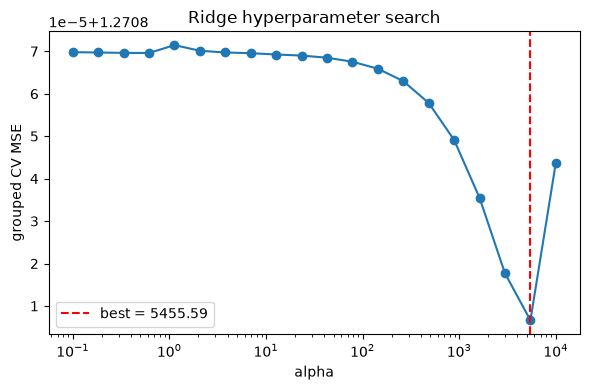

In [12]:
# Build training and test features
gene_prior, gene_prior_abs = compute_gene_prior(train_keys)
X_train = build_pairwise(train_keys, gene_prior, gene_prior_abs)
X_test  = build_pairwise(test_keys,  gene_prior, gene_prior_abs)

y_train = Y_train.values.ravel()
y_test  = Y_test.values.ravel()
groups_train = np.repeat([p for (c, p) in train_keys], ng)   # group = perturbation, for leakage-free CV
print(f"X_train {X_train.shape}, X_test {X_test.shape}")

# Find best alpha using grouped CV
alphas = np.logspace(-1, 4, 20)
n_splits = min(5, len(train_perts))
gkf = GroupKFold(n_splits=n_splits)
cv_mse = []
for a in alphas:
    pipe = Pipeline([("sc", StandardScaler()), ("rg", Ridge(alpha=a))])
    sc = cross_val_score(pipe, X_train, y_train, groups=groups_train, cv=gkf,
                         scoring="neg_mean_squared_error")
    cv_mse.append(-sc.mean())
best_alpha = float(alphas[int(np.argmin(cv_mse))])
print(f"best alpha: {best_alpha:.3f} (grouped {n_splits}-fold CV MSE = {min(cv_mse):.4f})")

plt.figure(figsize=(6, 4))
plt.plot(alphas, cv_mse, marker="o")
plt.axvline(best_alpha, color="r", ls="--", label=f"best = {best_alpha:.2f}")
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("grouped CV MSE")
plt.title("Ridge hyperparameter search")
plt.legend()
plt.tight_layout()
plt.show()

ridge = Pipeline([("sc", StandardScaler()), ("rg", Ridge(alpha=best_alpha))]).fit(X_train, y_train)
pred_ridge = reshape_pred(ridge.predict(X_test), test_keys)

### 3. Multilayer perceptron (simple)

A small neural network trained on the same features as the ridge regression. The model has one hidden layer (64 neurons) and is very simple for a neural network on purpose. For this size of dataset, a neural network might already overfit, but I chose it nevertheless, as I aloows me to have a nice comparison between different model complexities for this task.

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

class SimpleMLP(nn.Module):
    """One small hidden layer. Deliberately simple: the feature set is compact and there are only a
    few dozen perturbations, so extra depth / width mostly overfits."""
    def __init__(self, d_in, hidden=64, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, hidden), 
            nn.ReLU(), 
            nn.Dropout(dropout),
            nn.Linear(hidden, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(1)

def train_mlp(X, y, X_val, y_val, hidden=64, dropout=0.1, lr=1e-3, wd=1e-4, epochs=300, batch=4096, patience=20):
    """Fit the simple MLP, early-stopping on a validation split. No hyperparameter grid."""
    torch.manual_seed(SEED)
    model = SimpleMLP(X.shape[1], hidden, dropout).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    loss_fn = nn.MSELoss()

    X  = torch.tensor(X,  dtype=torch.float32);  y  = torch.tensor(y,  dtype=torch.float32)
    Xv = torch.tensor(X_val, dtype=torch.float32); yv = torch.tensor(y_val, dtype=torch.float32)

    best, best_state, wait = float("inf"), None, 0
    for _ in range(epochs):
        model.train()
        perm = torch.randperm(len(X))
        for i in range(0, len(X), batch):
            idx = perm[i:i + batch]
            xb, yb = X[idx].to(device), y[idx].to(device)
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            opt.step()
        model.eval()
        with torch.no_grad():
            vl = loss_fn(model(Xv.to(device)), yv.to(device)).item()
        if vl < best - 1e-6:
            best, best_state, wait = vl, {k: v.cpu().clone() for k, v in model.state_dict().items()}, 0
        else:
            wait += 1
            if wait >= patience:
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    return model

def predict_mlp(model, X):
    model.eval()
    with torch.no_grad():
        return model(torch.tensor(X, dtype=torch.float32, device=device)).cpu().numpy()

device: cuda


Split a quarter of the training perturbations off as a validation set for early stopping (held-out
test perturbations are never touched).

In [ ]:
# Split training perturbations into inner-train / validation
inner_perts, val_perts = train_test_split(
    sorted(train_perts), test_size=0.25, random_state=SEED
)
val_set = set(val_perts)

row_is_val = np.repeat([p in val_set for (c, p) in train_keys], ng)

# Scale using inner-training data only
scaler = StandardScaler().fit(X_train[~row_is_val])
Xtr_s  = scaler.transform(X_train[~row_is_val])
Xval_s = scaler.transform(X_train[row_is_val])
Xte_s  = scaler.transform(X_test)

# Small hyperparameter search - pretty much unnessesary as it is only a very simple model for comparison, but it doesn't hurt
grid = [(32, 0.0), (64, 0.0), (64, 0.1), (128, 0.1), (128, 0.2)]
results = []

for hidden, dropout in grid:
    m = train_mlp(
        Xtr_s, y_train[~row_is_val], Xval_s, y_train[row_is_val],
        hidden=hidden, dropout=dropout, epochs=300, patience=20
    )
    pred = predict_mlp(m, Xval_s)
    results.append((hidden, dropout, np.mean((pred - y_train[row_is_val])**2)))

best_hidden, best_dropout, best_mse = min(results, key=lambda x: x[2])

print(f"Best: hidden={best_hidden}, dropout={best_dropout}, val MSE={best_mse:.4f}")

# Train final model and predict held-out perturbations
mlp = train_mlp(
    Xtr_s, y_train[~row_is_val], Xval_s, y_train[row_is_val],
    hidden=best_hidden, dropout=best_dropout, epochs=300, patience=20
)

pred_mlp = reshape_pred(predict_mlp(mlp, Xte_s), test_keys)

Best: hidden=128, dropout=0.2, val MSE=1.2481


## Evaluation

In [15]:
preds = {
    "zero (baseline)":      pred_zero,
    "cond-mean (baseline)": pred_cmean,
    "ridge":                pred_ridge,
    "mlp":                  pred_mlp,
}
scores = {n: per_row_metrics(p, Y_test) for n, p in preds.items()}

# Mean of every metric with a bootstrap 95% CI over the held-out perturbation rows
def fmt(vals):
    m, lo, hi = bootstrap_ci(vals)
    return f"{m:.3f} [{lo:.3f}, {hi:.3f}]"

metric_cols = ["roc_auc", "pr_auc", "r_all", "rho_all", "r_de"]
summary = pd.DataFrame({m: {n: fmt(scores[n][m]) for n in preds} for m in metric_cols})
print("Held-out performance  (mean [95% bootstrap CI] over perturbation rows)")
print(summary.to_string())

print("\nROC-AUC by condition:")
print(pd.DataFrame({n: scores[n].groupby("cond")["roc_auc"].mean() for n in preds}).round(3).to_string())

Held-out performance  (mean [95% bootstrap CI] over perturbation rows)
                                   roc_auc                pr_auc                 r_all               rho_all                  r_de
zero (baseline)       0.500 [0.500, 0.500]  0.050 [0.050, 0.050]        nan [nan, nan]        nan [nan, nan]        nan [nan, nan]
cond-mean (baseline)  0.542 [0.528, 0.556]  0.109 [0.099, 0.120]  0.115 [0.089, 0.140]  0.045 [0.035, 0.054]  0.339 [0.220, 0.446]
ridge                 0.543 [0.528, 0.557]  0.110 [0.099, 0.121]  0.117 [0.091, 0.143]  0.045 [0.035, 0.054]  0.338 [0.219, 0.446]
mlp                   0.546 [0.532, 0.561]  0.112 [0.101, 0.123]  0.117 [0.091, 0.144]  0.045 [0.036, 0.055]  0.339 [0.219, 0.448]

ROC-AUC by condition:
            zero (baseline)  cond-mean (baseline)  ridge    mlp
cond                                                           
Co-culture              0.5                 0.530  0.530  0.533
Control                 0.5                 0.564  0.565  0

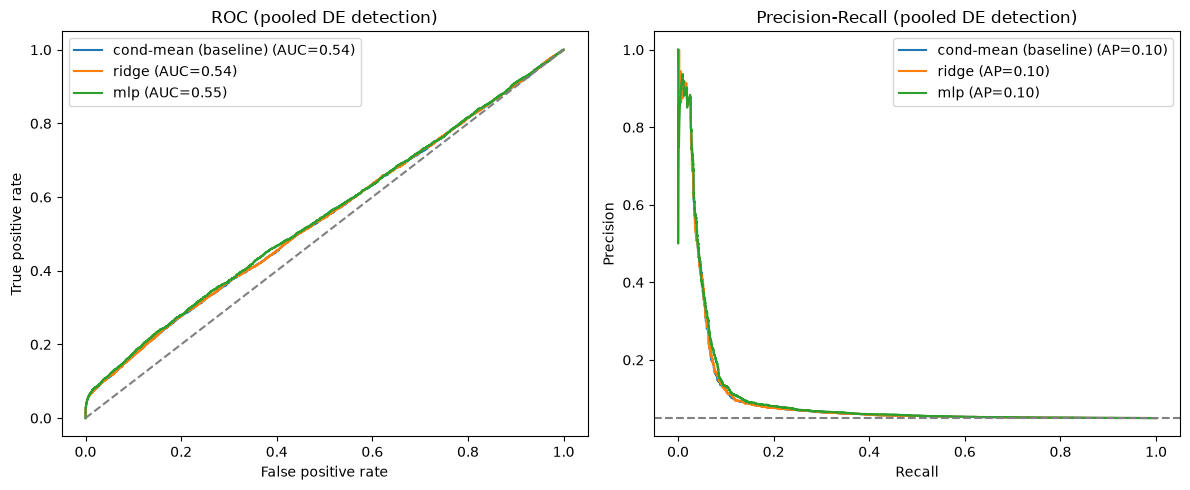

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
for n, p in preds.items():
    y, s = pooled_labels_scores(p, Y_test)
    if s.std() == 0:            # the zero baseline has a constant score -> undefined curve
        continue
    fpr, tpr, _ = roc_curve(y, s)
    prec, rec, _ = precision_recall_curve(y, s)
    ax[0].plot(fpr, tpr, label=f"{n} (AUC={roc_auc_score(y, s):.2f})")
    ax[1].plot(rec, prec, label=f"{n} (AP={average_precision_score(y, s):.2f})")

ax[0].plot([0, 1], [0, 1], "--", c="grey")
ax[0].set(xlabel="False positive rate", ylabel="True positive rate", title="ROC (pooled DE detection)")
ax[1].axhline(N_DE / N_TARGET_GENES, ls="--", c="grey")
ax[1].set(xlabel="Recall", ylabel="Precision", title="Precision-Recall (pooled DE detection)")
for a in ax:
    a.legend()
plt.tight_layout()
plt.show()

We also calculate accuracy, precision, recall and F1 using |log2FC| $\geq$ 1 as the cutoff. However, these scores depend on this chosen cutoff, so ROC-AUC and PR-AUC are more useful for comparing the models.

In [17]:
for name, p in preds.items():
    evaluate(name, p, Y_test)
    print("-" * 60)

=== zero (baseline) ===   (DE positive rate = 0.301)
accuracy          : 0.699
balanced acc.     : 0.500
precision         : 0.000
recall            : 0.000
f1                : 0.000
roc_auc           : 0.500
pr_auc            : 0.301

              precision    recall  f1-score   support

      not DE      0.699     1.000     0.823     41956
          DE      0.000     0.000     0.000     18044

    accuracy                          0.699     60000
   macro avg      0.350     0.500     0.412     60000
weighted avg      0.489     0.699     0.576     60000

------------------------------------------------------------
=== cond-mean (baseline) ===   (DE positive rate = 0.301)
accuracy          : 0.701
balanced acc.     : 0.505
precision         : 0.703
recall            : 0.012
f1                : 0.024
roc_auc           : 0.520
pr_auc            : 0.334

              precision    recall  f1-score   support

      not DE      0.701     0.998     0.824     41956
          DE      0.703   

gene_prior         0.2099
gene_prior_abs     0.0058
coexpr             0.0055
is_self            0.0029
cond=Co-culture    0.0004
cond=Control       0.0003
cond=IFNγ          0.0001
pathway_jaccard    0.0000


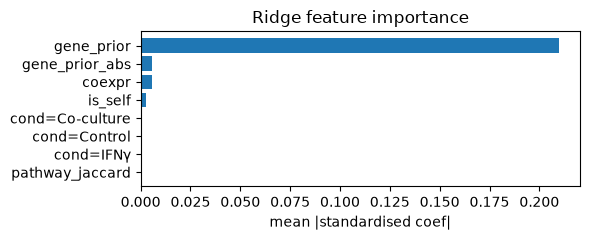

In [18]:
feature_importance(ridge)

100%|██████████| 500/500 [00:00<00:00, 572.95it/s]


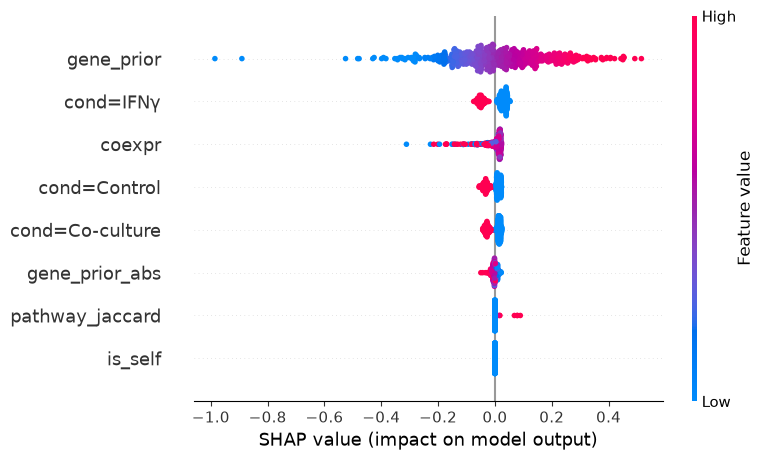

MLP SHAP Feature Importance:
gene_prior         0.1414
cond=IFNγ          0.0361
coexpr             0.0232
cond=Control       0.0204
cond=Co-culture    0.0194
gene_prior_abs     0.0060
pathway_jaccard    0.0007
is_self            0.0000


In [19]:
# MLP feature importance

# Use a smaller sample for SHAP (it's slow)
shap_sample_size = min(500, len(Xte_s))
sample_idx = np.random.choice(len(Xte_s), shap_sample_size, replace=False)
X_shap = Xte_s[sample_idx]

def mlp_predict(X):
    return predict_mlp(mlp, X).ravel()

# SHAP Kernel Explainer
explainer = shap.KernelExplainer(mlp_predict, shap.sample(Xte_s, 100))
shap_values = explainer.shap_values(X_shap)

# Plot
shap.summary_plot(shap_values, X_shap, feature_names=FEATURE_NAMES, show=False)
plt.tight_layout()
plt.show()

# Mean absolute SHAP value = feature importance
mean_abs_shap = np.abs(shap_values).mean(axis=0)
order = np.argsort(mean_abs_shap)[::-1]

print("MLP SHAP Feature Importance:")
for i in order:
    print(f"{FEATURE_NAMES[i]:18s} {mean_abs_shap[i]:.4f}")

ROC-AUC (mean [95% CI])  and  Wilcoxon vs cond-mean baseline
  zero (baseline)                0.500 [0.500, 0.500]  vs baseline: p=1.22e-05 (median dAUC=-0.047)
  cond-mean (baseline)           0.542 [0.528, 0.556]  (reference)
  ridge                          0.543 [0.528, 0.557]  vs baseline: p=0.221 (median dAUC=+0.002)
  mlp                            0.546 [0.532, 0.561]  vs baseline: p=0.0636 (median dAUC=+0.005)


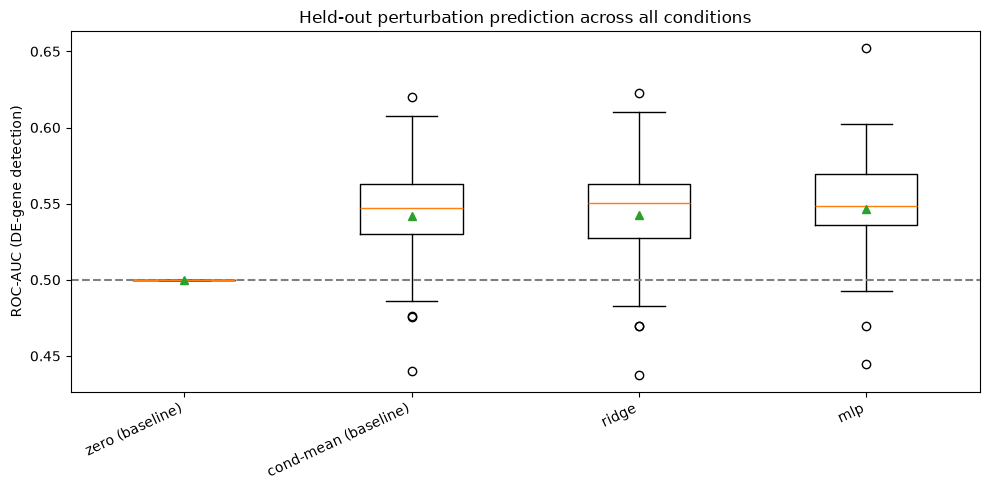

In [20]:
# Spread of per-row DE ROC-AUC across held-out perturbations & paired test of each model against cond-mean baseline
print("ROC-AUC (mean [95% CI])  and  Wilcoxon vs cond-mean baseline")
base = scores["cond-mean (baseline)"]["roc_auc"].values
for n in preds:
    v = scores[n]["roc_auc"].values
    m, lo, hi = bootstrap_ci(v)
    if n == "cond-mean (baseline)" or np.allclose(v, base):
        ptxt = "  (reference)"
    else:
        diff = v - base
        if np.allclose(diff, 0):
            ptxt = "  vs baseline: p=1.000"
        else:
            try:
                stat, pval = wilcoxon(v, base)
                ptxt = f"  vs baseline: p={pval:.3g} (median dAUC={np.median(diff):+.3f})"
            except ValueError:
                ptxt = "  vs baseline: n/a"
    print(f"  {n:30s} {m:.3f} [{lo:.3f}, {hi:.3f}]{ptxt}")

names = list(preds)
plt.figure(figsize=(10, 5))
plt.boxplot([scores[n]["roc_auc"] for n in names], showmeans=True)
plt.xticks(range(1, len(names) + 1), names, rotation=25, ha="right")
plt.axhline(0.5, ls="--", c="grey")
plt.ylabel("ROC-AUC (DE-gene detection)")
plt.title("Held-out perturbation prediction across all conditions")
plt.tight_layout()
plt.show()

## Biological interpretation: 
Which held-out perturbations are predicted well, and what do they share with the training set? 
Per held-out perturbation we show the ridge DE ROC-AUC alongside three metrics that should make a gene predictable: 
- whether the perturbed gene is included in the measured genes
- whether it is strongly co-expressed with the target genes
- whether it shares Reactome pathways with perturbations used during training

In [21]:
target_set = set(target_genes_list)
row_auc = scores["ridge"].groupby("pert")["roc_auc"].mean().sort_values(ascending=False)

recs = []
for p in row_auc.index:
    my_paths = gene_paths.get(p, EMPTY)
    shared = sum(len(my_paths & gene_paths.get(q, EMPTY)) > 0 for q in train_perts) if my_paths else 0
    recs.append(dict(perturbation=p,
                     ridge_roc_auc=round(float(row_auc[p]), 3),
                     self_measured=("yes" if p in target_set else "no"),
                     mean_abs_coexpr=round(float(np.abs(coexpr.get(p, np.zeros(ng))).mean()), 3),
                     train_perts_sharing_pathway=int(shared)))
bio = pd.DataFrame(recs)
print("\nBiological interpretation (by Ridge ROC-AUC):")
print(bio.to_string(index=False))

if bio["self_measured"].nunique() > 1:
    good = bio.loc[bio.self_measured == "yes", "ridge_roc_auc"].mean()
    bad  = bio.loc[bio.self_measured == "no",  "ridge_roc_auc"].mean()
    print(f"\nmean ridge ROC-AUC | self gene measured: {good:.3f} | not measured: {bad:.3f}")


Biological interpretation (by Ridge ROC-AUC):
perturbation  ridge_roc_auc self_measured  mean_abs_coexpr  train_perts_sharing_pathway
    RNASEH2A          0.571            no            0.004                            0
         NCL          0.570            no            0.022                            4
        ILF2          0.568            no            0.012                            7
       ROMO1          0.558            no            0.006                            0
       CCT6A          0.552            no            0.014                            1
      PET100          0.550            no            0.006                            5
       SNRPF          0.539            no            0.015                            8
        CCT3          0.536            no            0.014                            1
      RUVBL2          0.520            no            0.011                            1
       PSMA7          0.463            no            0.011               

Discussion

**Task and Approach**
Predicting the transcriptome changes for a gene that was not knocked out in the training data is very difficult, as it is a zero-shot prediction. Even though the knocked-out genes here usually act as parts of some program, allowing you to gain some insight into these other genes, they are still not all influenced in the same way. For getting more accurate predictions, something which would help a lot is to use data of the same gene being perturbed in a different cell type or for a different condition (so a complex model trained on lots of data to learn even complex and well-hidden patterns) or by using lots of additional data (e.g. which pathways the gene is in). In the ideal scenario, you would be doing both. As in this task, however, we are supposed to use only 50 perturbations in total (for training and testing), the first method can't be applied here, which is why we have to focus on the second approach: getting as many contextual insights as possible.

The best way to approach this problem I could think of was to try and turn the perturbations into log2FC (one average gene expression for each perturbation and condition) and then try to use information about the pathway (from Reactome), which genes are typically co-expressed in this experiment, and how a knockout influences the gene expression compared to the active gene in the training perturbations. Although this already gives me helpful information for predicting the perturbations, there is still always a lot of ambiguity in each of these features, making the predictions very hard. This, together with the fact that the model is only trained and tested on 50 perturbations in total, gives the model very little room to learn general patterns. Because of this exact problem, I deliberately chose simple models for this task, even adding only one hidden layer to the MLP (I still use MLP to have a comparison to a neural network, even if it may be very simple).

**Results and Analysis**
Looking at the final results for the two models as well as the stochastic baseline, we can see that all of them show an incredibly poor performance, barely above random guessing. The performance on the held-out perturbations shows that the cond-mean baseline (= predicts the average training perturbation for that condition) basically can't be reliably outperformed by either of the models when it comes to any of the metrics (AUC-ROC, PR-AUC, Pearson, Spearman and Pearson on the top 100 true DE genes). Both models also seem to have basically the same performance (with the MLP always being minimally better; not significant). Moreover, the condition-specific ROC-AUC curve shows that the models perform practically the same when it comes to predicting either the IFN-$\gamma$ or co-culture condition, while they are better at predicting the baseline (0.53 vs 0.56 respectively).

In the context of the bias-variance tradeoff, the models go from high bias and low variance (cond-mean) over ridge regression to the MLP (lowest bias, highest variance), with the MLP being the most flexible and able to fit more difficult patterns. In this task, however, variance does not seem to be the limiting factor, as all models plateau at essentially the same performance. Instead, the limit is set by how little signal the features carry, together with the noise in the data. So a more flexible model cannot improve on the baseline and better features would be needed rather than a bigger model.

For the features, the gene_prior (= mean |training log2FC| of gene j; responsiveness of a gene) is the most important in both models (in regression by far the most, in MLP not visible), meaning the target gene j's historical responsiveness matters more than condition. All other features are much less important in ridge regression and much less distinguishing in MLP. For further improving the model, the other features would need to be adapted and more meaningful ones added, but due to time reasons I wasn't able to play around with it much more and find better ones.

**Biological Interpretation**
At last, I tried to look into why certain held-out perturbations are predicted better or worse by looking at some of their key biological features. The results showed that perturbations were generally predicted better when the perturbed gene was itself measured, had stronger co-expression with target genes, or shared pathways with perturbations seen during training. This suggests that biological similarity between the held-out and training perturbations helps the model generalize, although the strength of these effects varies between perturbations.

To conclude, I think even though there are many places where this model can still be improved a lot, such as using more data, selecting better features, choosing an easier-to-predict test set or a less difficult task, etc., the model is still useful in allowing us to gain more insights into the problem as well as the behavior of the underlying data.